Ejemplo de regresión lineal con varianzas (incertidumbres) en la variable $y$

Las incertidumbres en la variable $y$ se muestran mediante barras de error.

Ver secciones 4.2.1 y 4.4 en: Andrés M. Somoza, Emilio Cuevas, Rafael Garcia Molina, Miguel Ortuño, Jesús Ruiz,Javier Abellán, Laboratorio de Física (Diego Marín, 2001)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.odr import *

In [2]:
# Función lineal
def Lineal(parameters, x):
     A, B = parameters
     y = np.multiply(A, x) + B 
     return y

In [3]:
# Datos inventados de x
x = [0.02, 0.04, 0.06, 0.08, 0.10, 0.12]

In [4]:
# Datos inventados de y (bastante "ruidosos")
y = [0.07, 0.124, 0.137, 0.192, 0.236, 0.245]

In [5]:
# Varianzas inventadas de cada dato y (exageradas)
y_err = [0.02, 0.02, 0.02, 0.02, 0.02, 0.02]

In [6]:
# Definimos el modelo (en este caso, lineal) para el ajuste mediante "Orthogonal distance regression"
lin_model = Model(Lineal)

In [8]:
# Creamos los datos reales, incluyendo los valores medios de x e y y las varianzas de y
data = RealData(x, y, sy=y_err)

In [9]:
# Inicialización del método "Orthogonal distance regression", asumiendo unos parámetros iniciales para el modelo dados por los elementos del vector beta0:
odr = ODR(data, lin_model, beta0=[0., 1.])

In [10]:
# Se hace la regresión
out = odr.run()

In [11]:
# Escritura de resultados mediante salida standard de ODR.
# Parámetros óptimos del modelo
# Incertidumbres de cada parámetro
# ...
out.pprint()

Beta: [1.86629112 0.03669296]
Beta Std Error: [0.16671244 0.01294637]
Beta Covariance: [[513.51448706 -35.9460155 ]
 [-35.9460155    3.096795  ]]
Residual Variance: 5.4123182556892844e-05
Inverse Condition #: 0.0033501617516424652
Reason(s) for Halting:
  Sum of squares convergence


In [12]:
print(f"R cuadrado: {out.cov_beta[0,1]*out.cov_beta[1,0]/(out.cov_beta[0,0]*out.cov_beta[1,1]):.6f}")

R cuadrado: 0.812524


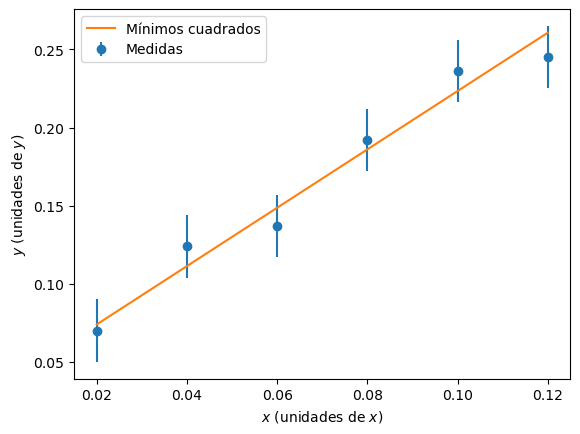

In [14]:
fit_y = Lineal(out.beta, x)
plt.errorbar(x, y, yerr=y_err, linestyle='None', marker='o', label='Medidas')
plt.plot(x, fit_y, label='Mínimos cuadrados')
plt.xlabel("$x$ (unidades de $x$)")
plt.ylabel("$y$ (unidades de $y$)")
plt.legend()
plt.show()